# Section 1 - Data Acquisition & EDA

## Step 1.1 - Load the dataset

In [16]:
# Cell 1: Install & imports
!pip install ucimlrepo -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [17]:
# Cell 2: Download via official UCI repo package
from ucimlrepo import fetch_ucirepo

heart_disease = fetch_ucirepo(id=45)  # id=45 -> Heart Disease (Cleveland)

X = heart_disease.data.features
y = heart_disease.data.targets

df = pd.concat([X, y], axis=1)
print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## Step 1.2 - Check for null values and data types



In [18]:
# Cell 3: Check missing values and dtypes
print(df.isnull().sum())
print(df.dtypes)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object


## Step 1.3 - Impute missing values & binarize

In [19]:
# Cell 4: Binarize target
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])

print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True))
#suggests mild imbalance
#not severe enough to need SMOTE or class weighting necessarily,
#but worth calling out in your report and worth keeping ROC-AUC/recall in view alongside accuracy later.

target
0    164
1    139
Name: count, dtype: int64
target
0    0.541254
1    0.458746
Name: proportion, dtype: float64


In [20]:
# Cell 5: Impute missing values
# ca -> discrete count (0-3), use mode
# thal -> categorical code (3,6,7), use mode
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

print(df.isnull().sum().sum(), "missing values remaining")

0 missing values remaining


## Step 1.4 - EDA Visualisations

/tmp/ipykernel_1546/4025954744.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette=['#4C72B0','#DD8452'])


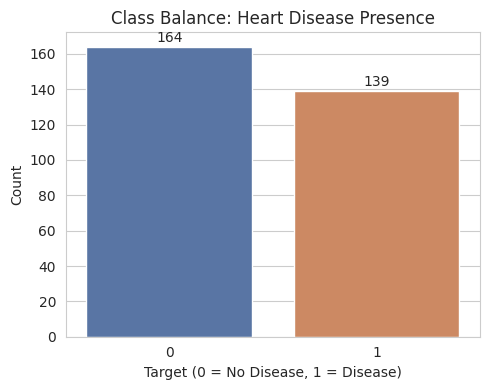

In [21]:
# Cell 6: Class balance
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df, palette=['#4C72B0','#DD8452'])
plt.title('Class Balance: Heart Disease Presence')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
for i, v in enumerate(df['target'].value_counts().sort_index()):
    plt.text(i, v + 3, str(v), ha='center')
plt.tight_layout()
plt.savefig('class_balance.png', dpi=150)
plt.show()

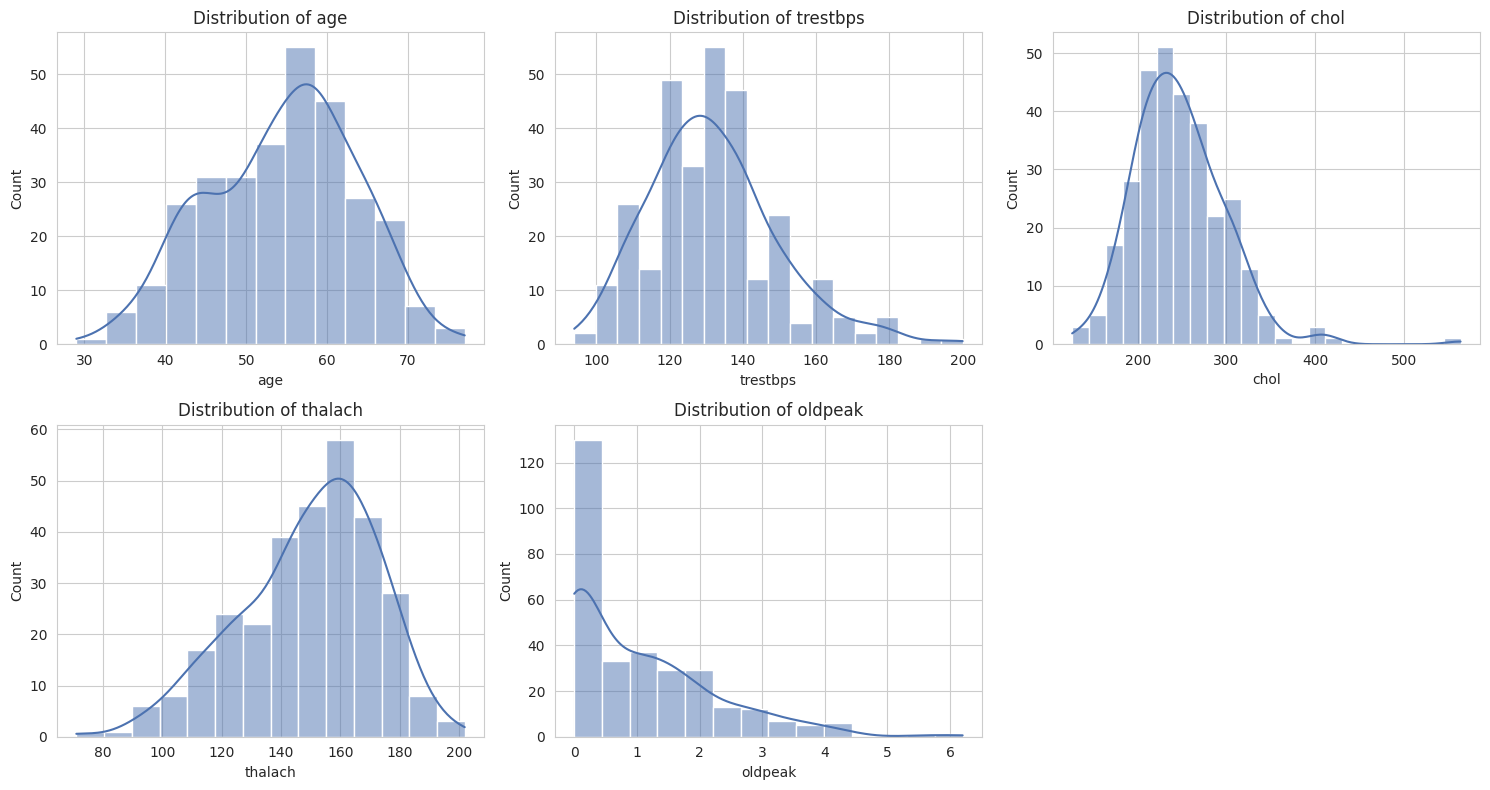

In [22]:
# Cell 7: Histogram with key numeric features
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'Distribution of {col}')

axes[-1].axis('off')  # hide the unused 6th subplot
plt.tight_layout()
plt.savefig('histograms.png', dpi=150)
plt.show()

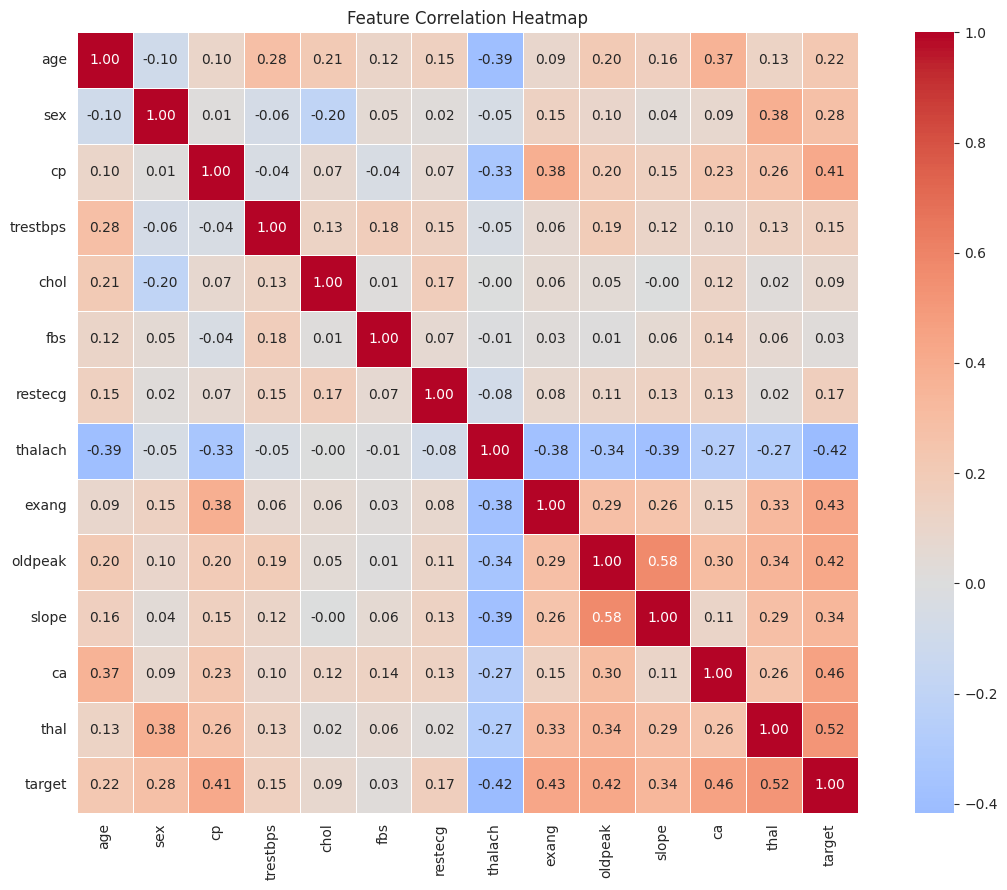

In [23]:
# Cell 8: Correlation heatmap
plt.figure(figsize=(12, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

/tmp/ipykernel_1546/746988444.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette=['#4C72B0','#DD8452'])
/tmp/ipykernel_1546/746988444.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette=['#4C72B0','#DD8452'])
/tmp/ipykernel_1546/746988444.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette=['#4C72B0','#DD8452'])


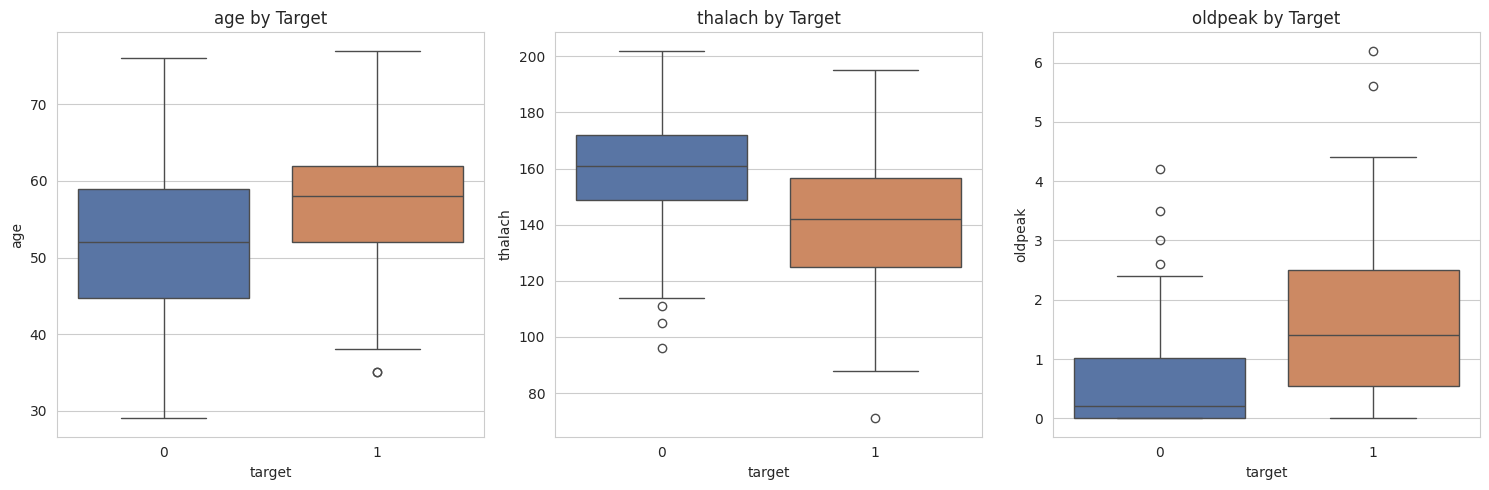

In [24]:
# Cell 9: Boxplots by target
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(['age', 'thalach', 'oldpeak']):
    sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette=['#4C72B0','#DD8452'])
    axes[i].set_title(f'{col} by Target')
plt.tight_layout()
plt.savefig('boxplots_by_target.png', dpi=150)
plt.show()

The dataset shows a mild class imbalance (54% no-disease, 46% disease-present), not severe enough to require resampling but noted for metric selection (prioritizing ROC-AUC/recall alongside accuracy). oldpeak is right-skewed while chol is approximately normal. The strongest correlates with heart disease presence are thal, ca, oldpeak, exang, cp, sex, and age (positive), and thalach (negative) — consistent with clinical expectations (reduced exercise capacity and ST depression indicating ischemia are associated with disease presence).

# Section 2 - Feature Engineering & Model Development

## Step 2.1 - Identifying feature types



* **Binary/categorical (already numeric-coded)**: sex, cp, fbs, restecg, exang, slope, ca, thal
* **Continuous (need scaling):** age, trestbps, chol, thalach, oldpeak




## Step 2.2 — Train/test split

In [25]:
# Cell 10: Train/test split
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
y = df['target']

# stratify:- 54/46 class ratio consistent in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(242, 13) (61, 13)
target
0    0.541322
1    0.458678
Name: proportion, dtype: float64
target
0    0.540984
1    0.459016
Name: proportion, dtype: float64


## Step 2.3 — Build the preprocessing pipeline

In [27]:
# Cell 11: Preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Column groups
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['cp', 'restecg', 'slope', 'thal']
binary_features = ['sex', 'fbs', 'exang', 'ca']  # ca kept as numeric (0-3 count), true binaries left as-is

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('bin', 'passthrough', binary_features)
    ]
)

# drop='first': on the one-hot encoder avoids the dummy variable trap
# handle_unknown='ignore' protects the pipeline at inference time in case an unexpected category ever comes in.
# ca is technically a count (0–3) so I left it as passthrough numeric rather than one-hot.

## Step 2.4 — Build Logistic Regression & Random Forest pipelines

In [28]:
# Cell 12: Model pipelines
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

## Step 2.5 — Cross-validation

Runs 5-fold CV on the training data only (test set stays untouched until final evaluation) and reports mean ± std for accuracy, precision, recall, and ROC-AUC for both models

In [30]:
# Cell 13: Cross-validation
from sklearn.model_selection import cross_validate

scoring = ['accuracy', 'precision', 'recall', 'roc_auc']

for name, pipe in [('Logistic Regression', log_reg_pipeline), ('Random Forest', rf_pipeline)]:
    scores = cross_validate(pipe, X_train, y_train, cv=5, scoring=scoring)
    print(f"\n{name}")
    for metric in scoring:
        vals = scores[f'test_{metric}']
        print(f"  {metric}: {vals.mean():.3f} (+/- {vals.std():.3f})")

# Logistic Regression is actually outperforming Random Forest across every metric

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



Logistic Regression
  accuracy: 0.839 (+/- 0.046)
  precision: 0.855 (+/- 0.075)
  recall: 0.783 (+/- 0.046)
  roc_auc: 0.902 (+/- 0.046)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



Random Forest
  accuracy: 0.793 (+/- 0.057)
  precision: 0.796 (+/- 0.071)
  recall: 0.738 (+/- 0.068)
  roc_auc: 0.885 (+/- 0.042)


## Step 2.6 — Hyperparameter tuning for Random Forest

Since RF is underperforming, giving it a fair shot with tuning before deciding on a final model

In [32]:
# Cell 14: Hyperparameter tuning - Random Forest
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7, None],
    'classifier__min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    rf_pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

rf_best_pipeline = grid_search.best_estimator_

Best params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 200}
Best CV ROC-AUC: 0.8982500591196242


## Step 2.7 — Tune Logistic Regression

In [33]:
# Cell 15: Hyperparameter tuning - Logistic Regression
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs']
}

grid_search_lr = GridSearchCV(
    log_reg_pipeline, param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search_lr.fit(X_train, y_train)

print("Best params:", grid_search_lr.best_params_)
print("Best CV ROC-AUC:", grid_search_lr.best_score_)

lr_best_pipeline = grid_search_lr.best_estimator_

Best params: {'classifier__C': 1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV ROC-AUC: 0.9022814544553676


## Step 2.8 — Final evaluation

In [34]:
# Cell 16: Final test set evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

final_model = lr_best_pipeline  # our chosen final model

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print("Test Set Performance")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Set Performance
Accuracy:  0.852
Precision: 0.806
Recall:    0.893
ROC-AUC:   0.957

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



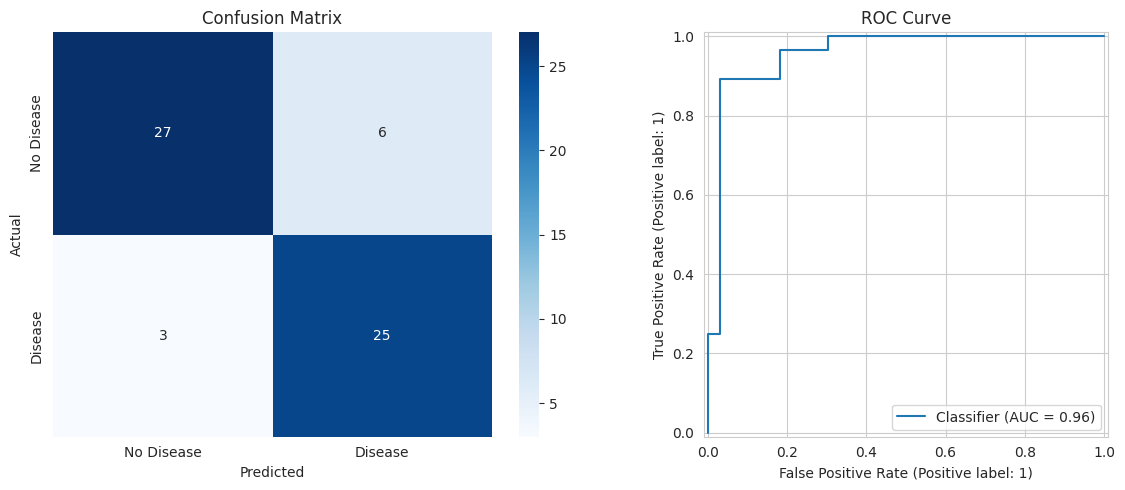

In [35]:
# Cell 17: Confusion matrix + ROC curve (for report visuals)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('ROC Curve')

plt.tight_layout()
plt.savefig('final_model_evaluation.png', dpi=150)
plt.show()

#"test set is small (n=61); CV estimates are more reliable indicators of generalization"

# Section 3 - Experiment Tracking with MLflow

## Step 3.1 — Install & setup

In [36]:
# Cell 18: Install MLflow
!pip install mlflow -q

import mlflow
import mlflow.sklearn

mlflow.set_experiment("heart-disease-classification")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2

2026/07/08 12:17:21 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/08 12:17:21 INFO mlflow.store.db.utils: Updating database tables
2026/07/08 12:17:24 INFO mlflow.tracking.fluent: Experiment with name 'heart-disease-classification' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1783513044940, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783513044940, lifecycle_stage='active', name='heart-disease-classification', tags={}, trace_location=None, workspace='default'>

## Step 3.2 — Log all four runs

In [38]:
# Cell 19: Log Logistic Regression (default)
with mlflow.start_run(run_name="logistic_regression_default"):
    log_reg_pipeline.fit(X_train, y_train)
    y_pred = log_reg_pipeline.predict(X_test)
    y_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("C", 1.0)
    mlflow.log_param("penalty", "l2")

    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred))
    mlflow.log_metric("precision", precision_score(y_test, y_pred))
    mlflow.log_metric("recall", recall_score(y_test, y_pred))
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_proba))

    mlflow.sklearn.log_model(log_reg_pipeline, "model", serialization_format="pickle")

2026/07/08 12:20:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/08 12:20:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [39]:
# Cell 20: Log Random Forest (default)
with mlflow.start_run(run_name="random_forest_default"):
    rf_pipeline.fit(X_train, y_train)
    y_pred = rf_pipeline.predict(X_test)
    y_proba = rf_pipeline.predict_proba(X_test)[:, 1]

    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", "None")

    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred))
    mlflow.log_metric("precision", precision_score(y_test, y_pred))
    mlflow.log_metric("recall", recall_score(y_test, y_pred))
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_proba))

    mlflow.sklearn.log_model(rf_pipeline, serialization_format="pickle")

2026/07/08 12:21:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [41]:
# Cell 21: Log Logistic Regression (tuned) - this is our FINAL model
with mlflow.start_run(run_name="logistic_regression_tuned_FINAL"):
    y_pred = lr_best_pipeline.predict(X_test)
    y_proba = lr_best_pipeline.predict_proba(X_test)[:, 1]

    mlflow.log_params(grid_search_lr.best_params_)
    mlflow.log_metric("cv_roc_auc", grid_search_lr.best_score_)
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred))
    mlflow.log_metric("precision", precision_score(y_test, y_pred))
    mlflow.log_metric("recall", recall_score(y_test, y_pred))
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_proba))

    mlflow.log_artifact('final_model_evaluation.png')
    mlflow.sklearn.log_model(lr_best_pipeline, serialization_format="pickle")
    mlflow.set_tag("final_model", "true")

2026/07/08 12:22:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [42]:
# Cell 22: Log Random Forest (tuned)
with mlflow.start_run(run_name="random_forest_tuned"):
    y_pred = rf_best_pipeline.predict(X_test)
    y_proba = rf_best_pipeline.predict_proba(X_test)[:, 1]

    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("cv_roc_auc", grid_search.best_score_)
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred))
    mlflow.log_metric("precision", precision_score(y_test, y_pred))
    mlflow.log_metric("recall", recall_score(y_test, y_pred))
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_proba))

    mlflow.sklearn.log_model(rf_best_pipeline, "model", serialization_format="pickle")

2026/07/08 12:24:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/08 12:24:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


## Step 3.3 — View MLflow UI in Colab
Colab can't directly open MLflow's web server on localhost, so we tunnel it

In [49]:
# Cell 23: Install and launch MLflow UI via ngrok tunnel
!pip install pyngrok -q

from pyngrok import ngrok
import subprocess
from google.colab import userdata

NGROK_TOKEN = userdata.get('NGROK_TOKEN') # Set your token under keys
ngrok.set_auth_token(NGROK_TOKEN)

mlflow_process.terminate()
time.sleep(2)

# Start MLflow UI in background
mlflow_process = subprocess.Popen(["mlflow", "ui", "--host", "0.0.0.0", "--port", "5000"])

import time
time.sleep(5)  # give it a moment to start

# Open a tunnel
public_url = ngrok.connect(5000)
print("MLflow UI:", public_url)

MLflow UI: NgrokTunnel: "https://imprint-entangled-grove.ngrok-free.dev" -> "http://localhost:5000"


MLflow's underlying Flask dev server is rejecting the request because the Host header ngrok sends doesn't match what it expects.

In [47]:
# Cell 24: Fallback - view runs directly in notebook (no tunnel needed)
runs_df = mlflow.search_runs(experiment_names=["heart-disease-classification"])
display(runs_df[['tags.mlflow.runName', 'params.model_type',
                  'metrics.accuracy', 'metrics.precision',
                  'metrics.recall', 'metrics.roc_auc']])

,tags.mlflow.runName,params.model_type,metrics.accuracy,metrics.precision,metrics.recall,metrics.roc_auc
0,random_forest_tuned,None,0.918033,0.896552,0.928571,0.969697
1,logistic_regression_tuned_FINAL,None,0.852459,0.806452,0.892857,0.956710
2,logistic_regression_tuned_FINAL,None,0.852459,0.806452,0.892857,0.956710
3,random_forest_default,RandomForest,0.901639,0.843750,0.964286,0.954545
4,logistic_regression_default,LogisticRegression,0.852459,0.806452,0.892857,0.956710
5,logistic_regression_default,LogisticRegression,0.852459,0.806452,0.892857,0.956710


# Section 4 - Model Packaging & Reproducbility

## Step 4.1 — Saving the final model

In [50]:
# Cell 25: Save final model with pickle
import pickle
import os

os.makedirs('model', exist_ok=True)

with open('model/heart_disease_pipeline.pkl', 'wb') as f:
    pickle.dump(lr_best_pipeline, f)

print("Model saved successfully")
print("File size:", os.path.getsize('model/heart_disease_pipeline.pkl'), "bytes")

Model saved successfully
File size: 3358 bytes


## Step 4.2 — Verifying reproducibility (reload and test)

In [51]:
# Cell 26: Reload model and verify predictions match
with open('model/heart_disease_pipeline.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Test on a sample row from X_test
sample = X_test.iloc[[0]]
original_pred = lr_best_pipeline.predict_proba(sample)[:, 1]
loaded_pred = loaded_model.predict_proba(sample)[:, 1]

print("Original model prediction:", original_pred)
print("Loaded model prediction:  ", loaded_pred)
print("Match:", abs(original_pred[0] - loaded_pred[0]) < 1e-9)

Original model prediction: [0.21801422]
Loaded model prediction:   [0.21801422]
Match: True


## Step 4.3 — Generating requirements.txt

In [52]:
# Cell 27: Generate requirements.txt with pinned versions
import sklearn, pandas, numpy, mlflow

requirements = f"""scikit-learn=={sklearn.__version__}
pandas=={pandas.__version__}
numpy=={numpy.__version__}
mlflow=={mlflow.__version__}
flask==3.0.3
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print(requirements)

scikit-learn==1.6.1
pandas==2.2.2
numpy==2.0.2
mlflow==3.14.0
flask==3.0.3

